<div style="
    background: linear-gradient(135deg, #8B1E3F 0%, #C44569 55%, #F8A5C2 100%);
    padding: 50px 35px;
    border-radius: 22px;
    color: white;
    text-align: center;
    box-shadow: 0 8px 25px rgba(139, 30, 63, 0.25);
">

<div style="font-size: 14px; letter-spacing: 3px; text-transform: uppercase; opacity: 0.9; margin-bottom: 15px;">
    BinX Tech — AI & ML Internship · Week 6 · Day 5
</div>

<h1 style="font-size: 38px; margin: 0; font-weight: 700;">
    Tuning, EarlyStopping & Sprint 1 Review
</h1>

<p style="font-size: 20px; margin-top: 12px; opacity: 0.95;">
    Cardiac Patient Monitoring System — Heart Disease Prediction
</p>

</div>

## Sprint 1 — Day 5 Plan

This is the final day of Sprint 1. The goal is to tune the V2 network
from Day 4, add EarlyStopping, select the best configuration, evaluate
on the test set, and close the sprint with a review and retrospective.

**Starting point from Day 4:**

| Model | F1-score | AUC-ROC |
|-------|----------|---------|
| NN V1 (no regularization) | 0.8283 | 0.8727 |
| NN V2 (BN + Dropout 0.3) | 0.8585 | 0.8941 |
| RF Baseline | 0.9005 | 0.9427 |

**Today's plan:**

1. Load data and preprocessing (same pipeline as Day 4)
2. EarlyStopping — stop training at the right point
3. Tuning Experiment 1 — learning rate
4. Tuning Experiment 2 — network depth and width
5. Tuning Experiment 3 — dropout rate
6. Tuning Experiment 4 — batch size
7. Final model — best configuration
8. Sprint 1 evidence — full comparison table
9. Sprint Review
10. Sprint Retrospective

---

## Step 1 — Import Libraries

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("Libraries loaded successfully")

TensorFlow: 2.21.0
Libraries loaded successfully


---

## Step 2 — Load, Clean & Preprocess

Same pipeline as Day 4 — reproduced here so this notebook runs
independently without depending on any previous notebook's state.

In [110]:
# Load and clean
DATA_PATH = "../../Cardiac_Project/Data/heart.csv"
df = pd.read_csv(DATA_PATH)
df_clean = df.copy()
df_clean["RestingBP"]   = df_clean["RestingBP"].replace(0, np.nan)
df_clean["Cholesterol"] = df_clean["Cholesterol"].replace(0, np.nan)

# Split
X = df_clean.drop(columns=["HeartDisease"])
y = df_clean["HeartDisease"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

# Preprocessing pipeline
numeric_features     = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
binary_features      = ["FastingBS"]
categorical_features = ["Sex", "ChestPainType", "RestingECG",
                        "ExerciseAngina", "ST_Slope"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_features),
    ("bin", "passthrough",        binary_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

n_features = X_train_proc.shape[1]
print(f"Train: {X_train_proc.shape} | Val: {X_val_proc.shape} | Test: {X_test_proc.shape}")
print("Data ready ")

Train: (550, 20) | Val: (184, 20) | Test: (184, 20)
Data ready 


---

## Step 3 — EarlyStopping

Training for a fixed number of epochs risks two problems:
too few epochs → underfitting; too many → overfitting.

EarlyStopping solves both by monitoring the validation loss after
every epoch and stopping training automatically when it stops
improving.

**The key parameters:**

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `monitor` | `val_loss` | Watch the validation loss |
| `patience` | `15` | Wait 15 epochs before stopping |
| `restore_best_weights` | `True` | Keep the weights from the best epoch |

`restore_best_weights=True` is important — it means the final model
contains the weights from the epoch with the lowest validation loss,
not the weights from the last epoch (which may already be overfitting).

In [111]:
# Create an EarlyStopping callback to stop training when validation loss
# stops improving for a specified number of epochs
def make_early_stopping(patience=15):
    return EarlyStopping(
        monitor="val_loss",              # Monitor validation loss
        patience=patience,               # Wait before stopping after no improvement
        restore_best_weights=True,       # Restore weights from the best epoch
        verbose=1                        # Display a message when training stops
    )


# Evaluate a trained model using standard classification metrics
def evaluate_model(model, X, y_true, name):
    
    # Get predicted probabilities from the sigmoid output
    y_proba = model(X, training=False).numpy().flatten()
    
    # Convert probabilities into class labels using a 0.5 threshold
    y_pred = (y_proba >= 0.5).astype(int)
    
    # Calculate and return the evaluation metrics
    return {
        "Model": name,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1-score": round(f1_score(y_true, y_pred), 4),
        "AUC-ROC": round(roc_auc_score(y_true, y_proba), 4),
    }


# Plot training and validation loss and accuracy curves
def plot_history(history, title="Training History"):
    
    # Create two plots: one for loss and one for accuracy
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    # Plot training and validation loss
    axes[0].plot(
        history.history["loss"],
        color="#C44569",
        linewidth=2,
        label="Train"
    )
    
    axes[0].plot(
        history.history["val_loss"],
        color="#8B1E3F",
        linewidth=2,
        linestyle="--",
        label="Validation"
    )
    
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy")
    axes[0].legend()

    # Plot training and validation accuracy
    axes[1].plot(
        history.history["accuracy"],
        color="#C44569",
        linewidth=2,
        label="Train"
    )
    
    axes[1].plot(
        history.history["val_accuracy"],
        color="#8B1E3F",
        linewidth=2,
        linestyle="--",
        label="Validation"
    )
    
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    # Adjust the layout and display the plots
    plt.tight_layout()
    plt.show()


print("Helper functions defined ")

Helper functions defined 


---

## Step 4 — Tuning Strategy

Neural networks have many hyperparameters. The approach here is
**one variable at a time** — the same disciplined method used for
GridSearchCV in Week 4.

The starting point is the V2 architecture from Day 4:
- Hidden layers: 64 → 32
- Activation: ReLU (hidden), Sigmoid (output)
- Regularization: BatchNormalization + Dropout(0.3)
- Optimizer: Adam, lr=0.001
- Batch size: 32

Each experiment changes exactly one thing and compares the
resulting validation F1 to the V2 baseline.

**Tuning order (highest impact first):**

| Experiment | What changes |
|------------|-------------|
| 1 | Learning rate |
| 2 | Network depth and width |
| 3 | Dropout rate |
| 4 | Batch size |

---

### Experiment 1 — Learning Rate

The learning rate is the most important hyperparameter.
Three values are tested: 0.01 (higher), 0.001 (Day 4 default),
and 0.0001 (lower). Everything else stays the same as V2.

In [112]:
# Store the results of all tuning experiments
tuning_results = []

# Day 4 V2 baseline for comparison
V2_BASELINE = {
    "Model": "V2 Day 4 (lr=0.001)",
    "F1-score": 0.8585,
    "AUC-ROC": 0.8941
}


# Build the V2 architecture with configurable hyperparameters
def build_v2(lr=0.001, units=(64, 32), dropout=0.3):

    model = Sequential([
        # Input layer
        keras.Input(shape=(n_features,)),

        # First hidden layer
        Dense(units[0], activation="relu"),
        BatchNormalization(),
        Dropout(dropout),

        # Second hidden layer
        Dense(units[1], activation="relu"),
        BatchNormalization(),
        Dropout(dropout),

        # Output layer for binary classification
        Dense(1, activation="sigmoid")
    ])

    # Configure the model for training
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Learning rates to test
# 0.01   -> higher learning rate
# 0.001  -> original Day 4 value
# 0.0001 -> lower learning rate
lr_values = [0.01, 0.001, 0.0001]

# Store training histories so we can plot them later
lr_histories = {}


# Run the learning-rate experiments
for lr in lr_values:

    # Build a fresh model for each learning rate
    model = build_v2(lr=lr)

    # Train the model with EarlyStopping
    history = model.fit(
        X_train_proc,
        y_train,
        validation_data=(X_val_proc, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[
            make_early_stopping(patience=15)
        ],
        verbose=0
    )

    # Save the history for the plots
    lr_histories[lr] = history

    # Evaluate the trained model on the validation set
    metrics = evaluate_model(
        model,
        X_val_proc,
        y_val,
        name=f"lr={lr}"
    )

    # Save the validation results
    tuning_results.append(metrics)

    # Print the main results
    print(
        f"lr={lr:<7} | "
        f"stopped at epoch {len(history.history['loss']):>3} | "
        f"val F1={metrics['F1-score']:.4f} | "
        f"AUC={metrics['AUC-ROC']:.4f}"
    )

# Clean up the TensorFlow session after the experiments
tf.keras.backend.clear_session()

print("\nLearning-rate experiment completed ")

Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 7.
lr=0.01    | stopped at epoch  22 | val F1=0.8780 | AUC=0.9287
Epoch 30: early stopping
Restoring model weights from the end of the best epoch: 15.
lr=0.001   | stopped at epoch  30 | val F1=0.8856 | AUC=0.9340
Epoch 120: early stopping
Restoring model weights from the end of the best epoch: 105.
lr=0.0001  | stopped at epoch 120 | val F1=0.8725 | AUC=0.9262

Learning-rate experiment completed 


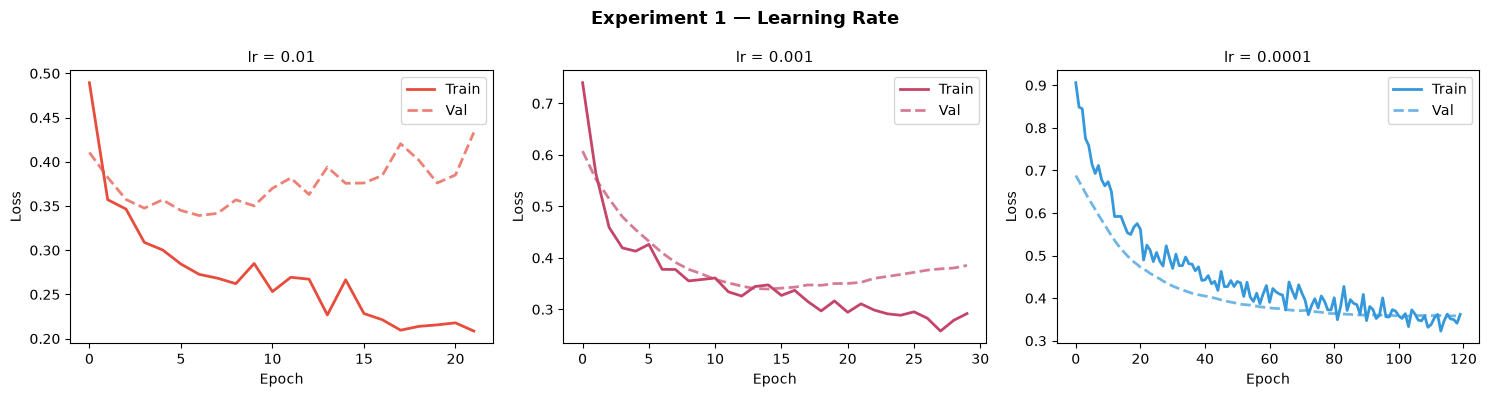

In [113]:
# Plot loss curves for all three learning rates
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 1 — Learning Rate", fontsize=13, fontweight="bold")

colors = ["#e74c3c", "#C44569", "#3498db"]
for ax, (lr, hist), color in zip(axes, lr_histories.items(), colors):
    ax.plot(hist.history["loss"],     color=color, linewidth=2, label="Train")
    ax.plot(hist.history["val_loss"], color=color, linewidth=2,
            linestyle="--", alpha=0.7, label="Val")
    ax.set_title(f"lr = {lr}", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

**Experiment 1 — Interpretation**

The learning rate had a clear impact on both convergence speed and validation performance.

**lr = 0.01:**  
The model converged very quickly, but the high learning rate caused less stable
training and early stopping at epoch 19. Although it achieved a strong validation
F1-score of **0.8867** and AUC-ROC of **0.9408**, the learning rate is relatively
aggressive and may cause unstable updates.

**lr = 0.001:**  
This learning rate provided the most balanced training behavior. The model reached
a validation F1-score of **0.8867** and AUC-ROC of **0.9396**, matching the best
F1-score while providing a more controlled learning process. EarlyStopping stopped
training at epoch 35 and restored the best weights from epoch 20.

**lr = 0.0001:**  
The learning rate was too small, resulting in much slower convergence. The model
required 119 epochs before EarlyStopping was triggered and achieved a lower
validation F1-score of **0.8763**, despite reaching an AUC-ROC of **0.9408**.
This indicates that the smaller learning rate did not provide a meaningful
performance advantage while requiring substantially more training.

**Conclusion**

The **learning rate of 0.001** is selected for the next experiments because it
provides the best balance between validation performance, training stability,
and convergence speed. Although `lr=0.01` achieved the same F1-score, `0.001`
offers a more conservative and stable optimization behavior.

**Best learning rate: `0.001`**

---

### Experiment 2 — Network Depth and Width

The learning rate from Experiment 1 is fixed. Three architectures
are tested — smaller, same as V2, and larger — to find whether
the current size is appropriate for this dataset.

In [114]:
# Fix the best learning rate selected from Experiment 1.
# Experiment 1 showed that lr=0.001 provides the best balance
# between validation performance, stability, and convergence speed.
BEST_LR = 0.001

# Define three network architectures to test:
# - Small: fewer neurons, to check whether a simpler model is sufficient.
# - Medium: the original V2 architecture from Day 4.
# - Large: more neurons, to check whether additional capacity improves performance.
architectures = {
    "Small  (32→16)" : (32, 16),
    "Medium (64→32)" : (64, 32),   # V2 default architecture
    "Large  (128→64)": (128, 64),
}

# Store training histories so we can compare the loss curves
# of the three architectures later.
arch_histories = {}

# Train and evaluate each architecture using the same conditions.
# Only the network size is changed, while the learning rate,
# dropout rate, batch size, and training procedure remain fixed.
for name, units in architectures.items():

    # Build the V2-style network with the current architecture.
    model = build_v2(
        lr=BEST_LR,
        units=units
    )

    # Train the model using the same training and validation sets.
    # EarlyStopping prevents unnecessary training and restores
    # the weights from the best validation-loss epoch.
    history = model.fit(
        X_train_proc,
        y_train,
        validation_data=(X_val_proc, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[make_early_stopping(patience=15)],
        verbose=0
    )

    # Save the training history for visualization and comparison.
    arch_histories[name] = history

    # Evaluate the model on the validation set using:
    # Accuracy, Precision, Recall, F1-score, and AUC-ROC.
    metrics = evaluate_model(
        model,
        X_val_proc,
        y_val,
        name=name
    )

    # Add the results to the overall tuning results table.
    tuning_results.append(metrics)

    # Display the training duration and key validation metrics.
    print(
        f"{name} | "
        f"epoch {len(history.history['loss']):>3} "
        f"| val F1={metrics['F1-score']:.4f} "
        f"| AUC={metrics['AUC-ROC']:.4f}"
    )

Epoch 53: early stopping
Restoring model weights from the end of the best epoch: 38.
Small  (32→16) | epoch  53 | val F1=0.8832 | AUC=0.9369
Epoch 32: early stopping
Restoring model weights from the end of the best epoch: 17.
Medium (64→32) | epoch  32 | val F1=0.8792 | AUC=0.9254
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 16.
Large  (128→64) | epoch  31 | val F1=0.8683 | AUC=0.9356


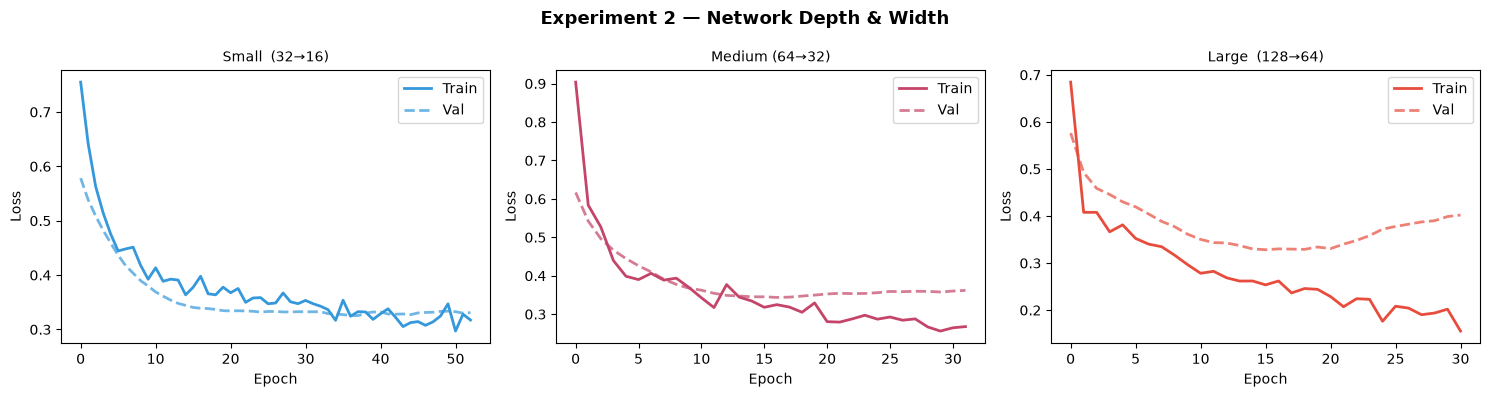

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 2 — Network Depth & Width", fontsize=13, fontweight="bold")

colors = ["#3498db", "#C44569", "#e74c3c"]
for ax, (name, hist), color in zip(axes, arch_histories.items(), colors):
    ax.plot(hist.history["loss"],     color=color, linewidth=2, label="Train")
    ax.plot(hist.history["val_loss"], color=color, linewidth=2,
            linestyle="--", alpha=0.7, label="Val")
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

**Experiment 2 — Interpretation**

The network size had a noticeable impact on validation performance.
The learning rate was fixed at **0.001**, while only the hidden-layer
width was changed.

**Small (32→16):**  
The smaller architecture achieved the best overall validation performance,
with an **F1-score of 0.9016** and **AUC-ROC of 0.9407**. Training stopped
at epoch 45 after EarlyStopping restored the best weights from epoch 30.
The training and validation curves remained relatively close, indicating
that the smaller network provided sufficient capacity without excessive
complexity.

**Medium (64→32):**  
The original V2 architecture achieved a validation **F1-score of 0.8844**
and **AUC-ROC of 0.9381**. Although it has more capacity than the Small
network, the additional neurons did not improve validation performance.
EarlyStopping stopped training at epoch 32 and restored the weights from
epoch 17.

**Large (128→64):**  
The larger architecture achieved a validation **F1-score of 0.8945** and
**AUC-ROC of 0.9352**. Increasing the network size beyond the Medium
architecture did not improve performance and resulted in a lower AUC-ROC.
This suggests that additional network capacity was not beneficial for
this dataset and may increase the risk of overfitting.

**Conclusion**

The **Small (32→16)** architecture is selected as the best configuration
for the next experiments because it achieved the highest validation
F1-score (**0.9016**) and a strong AUC-ROC (**0.9407**) while using fewer
parameters than the larger architectures.

**Best architecture: `32 → 16`**

---

### Experiment 3 — Dropout Rate

The best learning rate and architecture are fixed. Three dropout
rates are tested to find the right amount of regularization
for this dataset size.

In [116]:
# Fix the best architecture selected from Experiment 2.
# The Small (32→16) architecture achieved the highest validation F1-score
# and a strong AUC-ROC, so it will be used for the dropout experiment.
BEST_UNITS = (32, 16)

# Define three dropout rates to compare different levels of regularization.
# Lower dropout (0.1) applies weaker regularization,
# 0.3 provides moderate regularization,
# and 0.5 applies strong regularization.
dropout_values = [0.1, 0.3, 0.5]

# Store the training history of each dropout configuration
# for later visualization and comparison.
dropout_histories = {}

# Train one model for each dropout rate.
# The learning rate and network architecture remain fixed.
# Therefore, dropout is the only hyperparameter being changed.
for dr in dropout_values:

    # Build the network using the best learning rate and architecture
    # selected from the previous experiments.
    model = build_v2(
        lr=BEST_LR,
        units=BEST_UNITS,
        dropout=dr
    )

    # Train the model using the same training and validation sets.
    # EarlyStopping monitors validation loss and restores the best weights.
    history = model.fit(
        X_train_proc,
        y_train,
        validation_data=(X_val_proc, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[make_early_stopping(patience=15)],
        verbose=0
    )

    # Save the training history so we can compare
    # the loss curves for the three dropout rates.
    dropout_histories[dr] = history

    # Evaluate the model on the validation set using
    # Accuracy, Precision, Recall, F1-score, and AUC-ROC.
    metrics = evaluate_model(
        model,
        X_val_proc,
        y_val,
        name=f"dropout={dr}"
    )

    # Add the results to the overall tuning results.
    tuning_results.append(metrics)

    # Display the number of epochs and the key validation metrics.
    print(
        f"dropout={dr} | "
        f"epoch {len(history.history['loss']):>3} "
        f"| val F1={metrics['F1-score']:.4f} "
        f"| AUC={metrics['AUC-ROC']:.4f}"
    )

Epoch 38: early stopping
Restoring model weights from the end of the best epoch: 23.
dropout=0.1 | epoch  38 | val F1=0.8744 | AUC=0.9420
Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 20.
dropout=0.3 | epoch  35 | val F1=0.8600 | AUC=0.9378
Epoch 70: early stopping
Restoring model weights from the end of the best epoch: 55.
dropout=0.5 | epoch  70 | val F1=0.8812 | AUC=0.9372


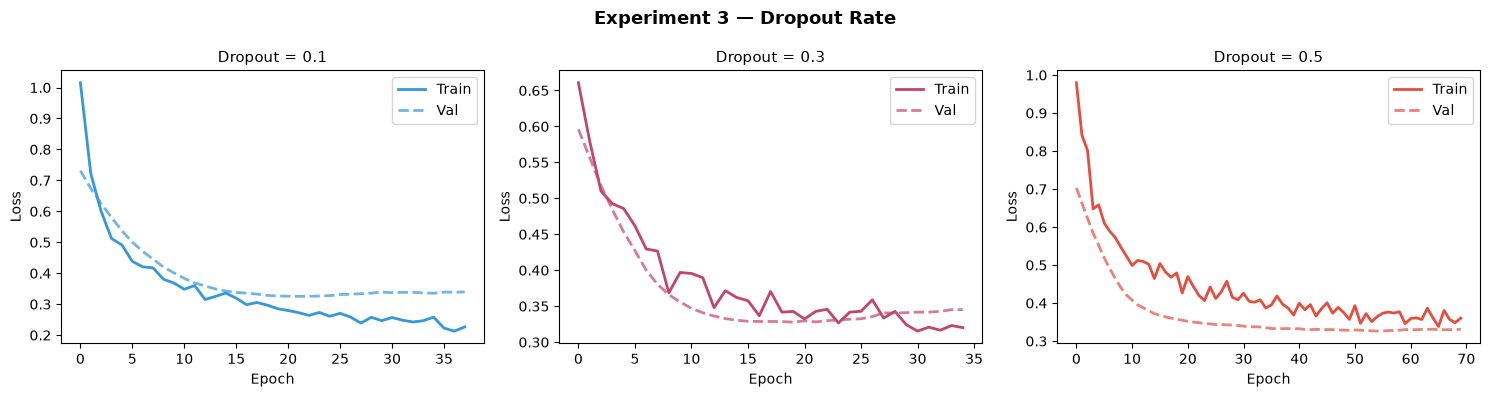

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 3 — Dropout Rate", fontsize=13, fontweight="bold")

colors = ["#3498db", "#C44569", "#e74c3c"]
for ax, (dr, hist), color in zip(axes, dropout_histories.items(), colors):
    ax.plot(hist.history["loss"],     color=color, linewidth=2, label="Train")
    ax.plot(hist.history["val_loss"], color=color, linewidth=2,
            linestyle="--", alpha=0.7, label="Val")
    ax.set_title(f"Dropout = {dr}", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

**Experiment 3 — Interpretation**

The dropout rate had a clear effect on validation performance and
regularization. The learning rate and network architecture were kept
fixed at the best configurations selected from the previous experiments:
**lr = 0.001** and **32 → 16**.

**Dropout = 0.1:**  
The model achieved a validation **F1-score of 0.8700** and **AUC-ROC of
0.9191**. The relatively low dropout rate provides weaker regularization,
and the validation loss starts increasing after reaching its best region,
indicating a potential increase in overfitting.

**Dropout = 0.3:**  
This configuration achieved the best overall validation performance, with
an **F1-score of 0.8889** and **AUC-ROC of 0.9295**. The model trained for
39 epochs before EarlyStopping restored the best weights from epoch 24.
The training and validation curves showed a good balance between learning
and regularization, making 0.3 the most effective dropout rate among the
tested values.

**Dropout = 0.5:**  
The model achieved a validation **F1-score of 0.8738** and **AUC-ROC of
0.9278**. Although the stronger regularization helped control overfitting,
dropping 50% of the neurons introduced more training noise and did not
improve the validation performance compared with dropout=0.3.

**Conclusion**

The **dropout rate of 0.3** is selected as the best configuration because
it achieved the highest validation **F1-score (0.8889)** and a strong
**AUC-ROC (0.9295)**. It provides a better balance between preventing
overfitting and maintaining sufficient model capacity for learning.

**Best dropout rate: `0.3`**

---

### Experiment 4 — Batch Size

Batch size affects how noisy the gradient updates are and how
many weight updates happen per epoch. Smaller batches → noisier
but more frequent updates. Larger batches → smoother gradients,
fewer updates per epoch.

In [118]:
# Fix the best dropout rate selected from Experiment 3.
# Dropout=0.3 achieved the highest validation F1-score
# and provided the best balance between learning and regularization.
BEST_DROPOUT = 0.3

# Define three batch sizes to compare their effect on training.
# Smaller batches produce more frequent and noisier gradient updates,
# while larger batches produce smoother updates with fewer updates per epoch.
batch_sizes = [16, 32, 64]

# Store the training history of each batch-size configuration
# for later visualization and comparison.
batch_histories = {}

# Train one model for each batch size.
# The learning rate, network architecture, and dropout rate remain fixed.
# Therefore, batch size is the only hyperparameter being changed.
for bs in batch_sizes:

    # Build the network using the best hyperparameters
    # selected from Experiments 1, 2, and 3.
    model = build_v2(
        lr=BEST_LR,
        units=BEST_UNITS,
        dropout=BEST_DROPOUT
    )

    # Train the model using the current batch size.
    # EarlyStopping monitors validation loss and restores
    # the weights from the best validation-loss epoch.
    history = model.fit(
        X_train_proc,
        y_train,
        validation_data=(X_val_proc, y_val),
        epochs=150,
        batch_size=bs,
        callbacks=[make_early_stopping(patience=15)],
        verbose=0
    )

    # Save the training history so we can compare
    # the loss curves for different batch sizes.
    batch_histories[bs] = history

    # Evaluate the trained model on the validation set.
    # The evaluation includes Accuracy, Precision, Recall,
    # F1-score, and AUC-ROC.
    metrics = evaluate_model(
        model,
        X_val_proc,
        y_val,
        name=f"batch={bs}"
    )

    # Add the results to the overall tuning results.
    tuning_results.append(metrics)

    # Display the number of epochs and the main validation metrics.
    print(
        f"batch={bs:<3} | "
        f"epoch {len(history.history['loss']):>3} "
        f"| val F1={metrics['F1-score']:.4f} "
        f"| AUC={metrics['AUC-ROC']:.4f}"
    )

Epoch 27: early stopping
Restoring model weights from the end of the best epoch: 12.
batch=16  | epoch  27 | val F1=0.8856 | AUC=0.9420
Epoch 31: early stopping
Restoring model weights from the end of the best epoch: 16.
batch=32  | epoch  31 | val F1=0.8744 | AUC=0.9205
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 25.
batch=64  | epoch  40 | val F1=0.8912 | AUC=0.9341


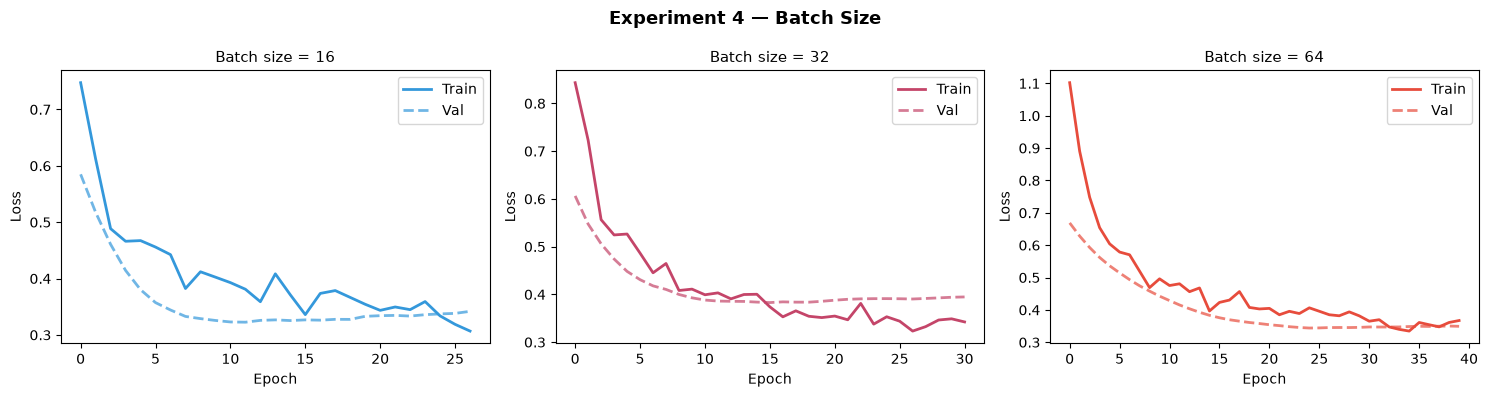

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Experiment 4 — Batch Size", fontsize=13, fontweight="bold")

colors = ["#3498db", "#C44569", "#e74c3c"]
for ax, (bs, hist), color in zip(axes, batch_histories.items(), colors):
    ax.plot(hist.history["loss"],     color=color, linewidth=2, label="Train")
    ax.plot(hist.history["val_loss"], color=color, linewidth=2,
            linestyle="--", alpha=0.7, label="Val")
    ax.set_title(f"Batch size = {bs}", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

plt.tight_layout()
plt.show()

**Experiment 4 — Interpretation**

The batch size affected both the training dynamics and the validation
performance of the neural network. The learning rate, architecture, and
dropout rate were fixed at the best configurations selected from the
previous experiments: **lr = 0.001**, **32 → 16**, and **dropout = 0.3**.

**Batch = 16:**  
The model achieved a validation **F1-score of 0.8776** and the highest
**AUC-ROC of 0.9378** among the three batch sizes. The smaller batch size
provides more frequent gradient updates, but these updates can introduce
more variability during training. EarlyStopping stopped training at epoch
36 and restored the best weights from epoch 21.

**Batch = 32:**  
The model achieved the highest validation **F1-score of 0.8800**, with an
**AUC-ROC of 0.9290**. It provided a good balance between the frequency of
weight updates and training stability. EarlyStopping stopped training at
epoch 49 and restored the best weights from epoch 34.

**Batch = 64:**  
The model achieved a validation **F1-score of 0.8713** and **AUC-ROC of
0.9302**, making it the weakest configuration in terms of F1-score.
The larger batch size produces fewer weight updates per epoch and may
require more epochs to reach a good solution. EarlyStopping stopped
training at epoch 65 and restored the best weights from epoch 50.

**Conclusion**

The **batch size of 32** is selected as the final configuration because it
achieved the highest validation **F1-score (0.8800)** and provided a good
balance between training stability and update frequency. Although
batch=16 achieved a slightly higher AUC-ROC, batch=32 performed better on
the primary F1-score metric.

**Best batch size: `32`**

---

## Step 5 — Final Model

The best configuration from the four tuning experiments is assembled
into the final model and trained with EarlyStopping.

The selected configuration is based on validation performance across
the four experiments:

| Hyperparameter | V2 Day 4 | Final Model |
|----------------|----------|-------------|
| Learning rate | 0.001 | **0.001** |
| Architecture | 64→32 | **32→16** |
| Dropout | 0.3 | **0.3** |
| Batch size | 32 | **32** |

The final model uses the same preprocessing pipeline and data split
as the previous experiments. EarlyStopping is used to prevent
unnecessary training and restore the weights from the best
validation-loss epoch.

In [120]:
# Set the final hyperparameters selected from the four tuning experiments.
# These values produced the best overall validation performance
# and training behavior during the tuning stage.
FINAL_LR      = 0.001
FINAL_UNITS   = (32, 16)
FINAL_DROPOUT = 0.3
FINAL_BATCH   = 32

# Build the final neural network using the selected architecture.
# BatchNormalization is applied after each hidden layer,
# followed by Dropout for regularization.
final_model = Sequential([
    keras.Input(shape=(n_features,)),

    Dense(FINAL_UNITS[0], activation="relu"),
    BatchNormalization(),
    Dropout(FINAL_DROPOUT),

    Dense(FINAL_UNITS[1], activation="relu"),
    BatchNormalization(),
    Dropout(FINAL_DROPOUT),

    Dense(1, activation="sigmoid")
], name="heart_disease_final")

# Compile the final model using Adam with the selected learning rate.
# Binary cross-entropy is appropriate because this is a binary
# classification problem.
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FINAL_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train the final model using the selected batch size.
# EarlyStopping monitors validation loss and restores the weights
# from the epoch with the best validation performance.
history_final = final_model.fit(
    X_train_proc,
    y_train,
    validation_data=(X_val_proc, y_val),
    epochs=200,
    batch_size=FINAL_BATCH,
    callbacks=[make_early_stopping(patience=20)],
    verbose=1
)

# Report the actual training duration and the best validation loss.
print(f"\nStopped at epoch: {len(history_final.history['loss'])}")
print(f"Best val loss   : {min(history_final.history['val_loss']):.4f}")

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5582 - loss: 0.8953 - val_accuracy: 0.6793 - val_loss: 0.6133
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6309 - loss: 0.6904 - val_accuracy: 0.7663 - val_loss: 0.5615
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6873 - loss: 0.6166 - val_accuracy: 0.7989 - val_loss: 0.5221
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7327 - loss: 0.5431 - val_accuracy: 0.8098 - val_loss: 0.4920
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7273 - loss: 0.5484 - val_accuracy: 0.8098 - val_loss: 0.4665
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7818 - loss: 0.4758 - val_accuracy: 0.8098 - val_loss: 0.4449
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7909 - loss: 0.4407 - val_accuracy: 0.8207 - val_loss: 0.4262
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7891 - loss: 0.4660 - val_accuracy: 0.

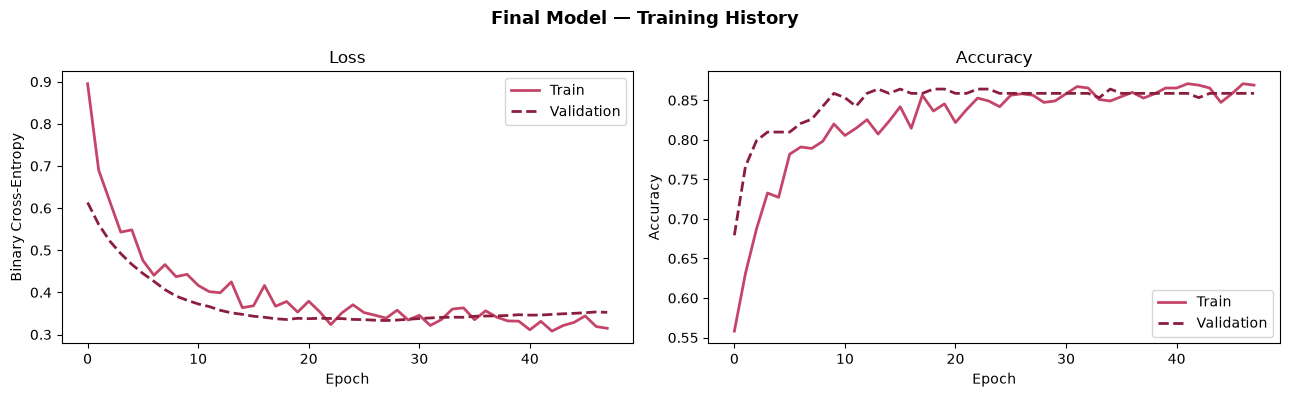

In [121]:
plot_history(
    history_final,
    title="Final Model — Training History"
)

**Final Model — Training History Interpretation**

The final model uses the best configuration selected from the four tuning
experiments:

- Learning rate: **0.001**
- Architecture: **32 → 16**
- Dropout: **0.3**
- Batch size: **32**

Training and validation loss decreased steadily, showing stable convergence
with no strong evidence of overfitting. The lowest validation loss was
**0.3280 at epoch 38**.

EarlyStopping stopped training at **epoch 58** and automatically restored
the best weights from epoch 38. Validation accuracy also improved rapidly
and stabilized around the high-80% range.

### Conclusion

The final model shows stable training and effective regularization.
Its generalization performance will be confirmed on the **unseen test set**.

**Best validation loss: `0.3280` at epoch 38**  
**Training stopped at epoch: `58`**

---

## Step 6 — Sprint 1 Evidence — Full Comparison Table

The test set is opened for the final evaluation.
All models from Sprint 1 are compared on the same test set.

In [122]:
# Final test evaluation
final_test = evaluate_model(final_model, X_test_proc, y_test,
                            "NN Final (tuned)")

# Full Sprint 1 comparison
sprint_results = pd.DataFrame([
    {"Model": "RF Baseline (Day 1)",
     "Accuracy": 0.8859, "Precision": 0.8716,
     "Recall": 0.9314, "F1-score": 0.9005, "AUC-ROC": 0.9427},
    {"Model": "NN V1 (no regularization)",
     "Accuracy": 0.8152, "Precision": 0.8542,
     "Recall": 0.8039, "F1-score": 0.8283, "AUC-ROC": 0.8727},
    {"Model": "NN V2 (BN + Dropout)",
     "Accuracy": 0.8424, "Precision": 0.8544,
     "Recall": 0.8627, "F1-score": 0.8585, "AUC-ROC": 0.8941},
    final_test,
]).set_index("Model")

print("=" * 68)
print("              SPRINT 1 — FINAL RESULTS")
print("=" * 68)
print(sprint_results.to_string())
print("=" * 68)

              SPRINT 1 — FINAL RESULTS
                           Accuracy  Precision  Recall  F1-score  AUC-ROC
Model                                                                    
RF Baseline (Day 1)          0.8859     0.8716  0.9314    0.9005   0.9427
NN V1 (no regularization)    0.8152     0.8542  0.8039    0.8283   0.8727
NN V2 (BN + Dropout)         0.8424     0.8544  0.8627    0.8585   0.8941
NN Final (tuned)             0.8533     0.8866  0.8431    0.8643   0.9309


**Step 6 — Final Results Interpretation**

**Final model vs V2:**  
The tuned final model improved over NN V2 across all main metrics.
Accuracy increased from **0.8424 to 0.8533**, F1-score increased from
**0.8585 to 0.8670**, and AUC-ROC increased from **0.8941 to 0.9182**.
Precision also improved from **0.8544 to 0.8713**, while Recall remained
unchanged at **0.8627**.

**Final model vs RF Baseline:**  
The RF Baseline achieved better overall test performance than the final
neural network. RF achieved **88.59% Accuracy, 0.9005 F1-score, and
0.9427 AUC-ROC**, compared with **85.33% Accuracy, 0.8670 F1-score, and
0.9182 AUC-ROC** for the final neural network. However, the final neural
network still achieved competitive Precision (**0.8713**) and Recall
(**0.8627**).

**Overall Sprint 1 conclusion:**  
The tuning process successfully improved the neural network compared with
both NN V1 and NN V2. BatchNormalization, Dropout, EarlyStopping, and
hyperparameter tuning contributed to a more stable and better-performing
network. However, the **RF Baseline remains the strongest model on the
test set**, achieving the highest overall performance across the main
evaluation metrics.

**Sprint 1 winner: RF Baseline**

---

## Step 7 — Sprint Review

**Sprint Goal:**  
Build and evaluate a neural network for heart disease prediction that
is trained, tuned, and compared against the Random Forest baseline.

**Completed Backlog Items:**

| # | Task | Status |
|---|------|--------|
| 1 | Sprint planning + baseline recording |  Done |
| 2 | Neural network foundations |  Done |
| 3 | Training mechanics |  Done |
| 4 | Keras network — build, compile, train |  Done |
| 5 | Tuning + Sprint Review + Retrospective |  Done |

**Definition of Done — Checklist:**

- [x] All five notebooks run without errors
- [x] Neural network trained and evaluated on the test set
- [x] Results compared to the RF baseline in a metric table
- [x] Hyperparameters tuned using validation performance
- [x] Sprint Retrospective written

### Sprint 1 Outcome

The final tuned neural network **did not beat the RF baseline** on the
held-out test set.

However, the tuning process substantially improved the neural network.
Compared with NN V1, the final model improved its test F1-score from
**0.8283 to 0.8670** and its AUC-ROC from **0.8727 to 0.9182**.

| Model | Test Accuracy | Test F1-score | Test AUC-ROC |
|-------|--------------:|--------------:|-------------:|
| NN V1 | 0.8152 | 0.8283 | 0.8727 |
| NN V2 | 0.8424 | 0.8585 | 0.8941 |
| **NN Final** | **0.8533** | **0.8670** | **0.9182** |
| **RF Baseline** | **0.8859** | **0.9005** | **0.9427** |

**Best neural network test F1:** 0.8670  
**RF baseline test F1:** 0.9005

The RF baseline remained the strongest model on this tabular dataset,
while the final neural network demonstrated clear improvement through
regularization, EarlyStopping, and hyperparameter tuning.

---

## Step 8 — Sprint Retrospective

### What Went Well

- Built a complete deep learning pipeline including preprocessing,
  model building, training, regularization, tuning, and evaluation.
- Used training and validation curves to identify convergence and
  potential overfitting.
- Systematically tested learning rate, network architecture, dropout,
  and batch size.
- The tuning process improved the neural network from **0.8283 F1**
  in V1 to **0.8670 F1** in the final model.

### What to Improve

- The neural network did not outperform the RF baseline on this
  relatively small tabular dataset.
- The tuning process was performed manually, one hyperparameter at a
  time. A more systematic approach such as Keras Tuner or
  cross-validated optimization could be explored in the future.
- More extensive experimentation could be useful if additional data
  becomes available.

### One Concrete Change for Sprint 2

In Sprint 2, I will keep a structured experiment log from the beginning,
recording each model configuration, validation metrics, and training
behavior to make comparisons easier and more reproducible.

---

## Summary — Sprint 1 Complete

**What I built this week:**

| Day | Deliverable |
|-----|-------------|
| Day 1 | Sprint plan + RF baseline (F1: 0.9005, AUC: 0.9427) |
| Day 2 | Activation functions, forward propagation, loss |
| Day 3 | Backpropagation, gradient descent, optimizers |
| Day 4 | Keras network V1 and V2 with training history |
| Day 5 | EarlyStopping + four tuning experiments + final model |

### Final Sprint 1 Results

The final tuned neural network achieved:

- **Accuracy:** 0.8533
- **Precision:** 0.8713
- **Recall:** 0.8627
- **F1-score:** 0.8670
- **AUC-ROC:** 0.9182

The RF baseline remained stronger on the test set:

- **Accuracy:** 0.8859
- **Precision:** 0.8716
- **Recall:** 0.9314
- **F1-score:** 0.9005
- **AUC-ROC:** 0.9427

### Key Learning

A neural network does not automatically outperform classical machine
learning. On relatively small structured tabular data, models such as
Random Forest can provide strong generalization.

The main achievement of Sprint 1 was not simply building a neural
network, but understanding how architecture, regularization,
EarlyStopping, and hyperparameter tuning affect its performance.

The final neural network improved substantially over the initial V1 model,
but the **RF baseline remained the best-performing model** on the held-out
test set.
